In [1]:
# magics: ensures that any changes to the modules loaded below will be re-loaded automatically
%load_ext autoreload
%autoreload 2

# load general packages
import numpy as np
import matplotlib.pyplot as plt

# load general packages
import numpy as np

# load modules related to this exercise
from model_zurcher import zurcher
from solve_NFXP import solve_NFXP
import estimate_NFXP as estimate
import warnings
# Turn off warnings: We turn of warnings as a result of overflow. This occurs as the optimizer will sometimes guess on non-feasible transition probabilities. 
warnings.filterwarnings("ignore", category=RuntimeWarning)


#  Exercise 3: Demand function

#### 1. Find the equilibrium distirbution of mileage

In [2]:
# Setup
do_settings = {
    'n': 90
}

model = zurcher(**do_settings)
solver = solve_NFXP()

#Read the data
data = model.read_busdata(bustypes=[1,2,3,4])
samplesize = data.shape[0]
uncond_R_P = sum(data.d)/samplesize

# Estimate
nfxp_model, optim_res, pnames, theta_hat, Avar, converged=estimate.estimate(model, solver,data)



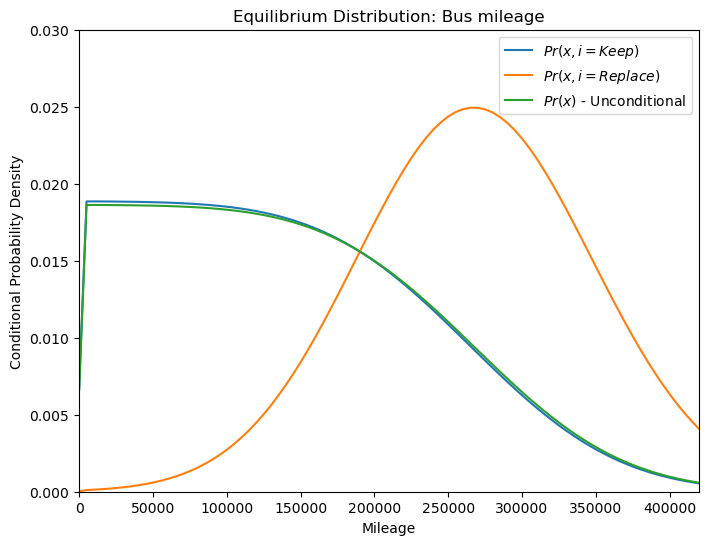

In [3]:
# Update the values with the estimated parameters
do_settings = {
    'n': 90,
    'RC': theta_hat[0],
    'c': theta_hat[1],
    'p': np.array(theta_hat[2:])
}
ev0 = np.zeros((model.n))
model_est = zurcher(**do_settings)
ev,pk = solver.poly(model_est.bellman,ev0, beta = model_est.beta, output=2)

# Find the probability functions
pp, pp_K, pp_R = model_est.eqb(pk)

fig = plt.figure(figsize=(8,6)) 
ax = fig.add_subplot(1,1,1)

ax.plot(model_est.grid*(model_est.max*1000)/model_est.n,pp_K/sum(pp_K))
ax.plot(model_est.grid*(model_est.max*1000)/model_est.n,pp_R/sum(pp_R))
ax.plot(model_est.grid*(model_est.max*1000)/model_est.n,pp/sum(pp))


ax.set_title(f'Equilibrium Distribution: Bus mileage')
ax.set_xlabel("Mileage")
ax.set_ylabel("Conditional Probability Density")
ax.set_xlim(0, 420000)
ax.set_ylim(0, 0.03)

plt.legend((f'$Pr(x, i=Keep)$',f'$Pr(x, i=Replace)$', f'$Pr(x)$ - Unconditional'))

plt.show()

#### 2. Find the scale of the cost function
a) How does the scale of the cost function relate to the estimate of RC and c? Hint: We implicitly assume that the standard deviation of the extreme value type 1 distributed shocks are equal to 1. 

b) What is the actual average replacement cost? Hint: Use the stuctural estimates and tabel III in  Rust (1987), "Optimal Replacement of GMC Bus Engines: An Emperical Model of Harold Zurcher (Table 3, Bus group 1,2,3,4)

c) How can we use this to estimate the scale of the cost function? Calculate the scale.

**Answer.** The EV1 shock scale is normalized to one, so $RC$ and $c$ are measured in units of the unobserved utility shock rather than dollars. If $s$ is dollars per utility unit, then $RC^{dollar}=sRC$ and $c^{dollar}=sc$. Rust's Table III gives an average observed replacement cost of $\$4,343$ for bus groups 1--4. Hence $s=4343/\widehat{RC}$; the code below computes this scale and can also convert the estimated maintenance-cost coefficient into dollars.

In [4]:
# Rust (1987), Table III: average observed replacement cost (bus groups 1--4)
average_replacement_cost = 4343
scale = average_replacement_cost / model_est.RC
scale

np.float64(445.1739897184751)

#### 3. Find the implied Demand function

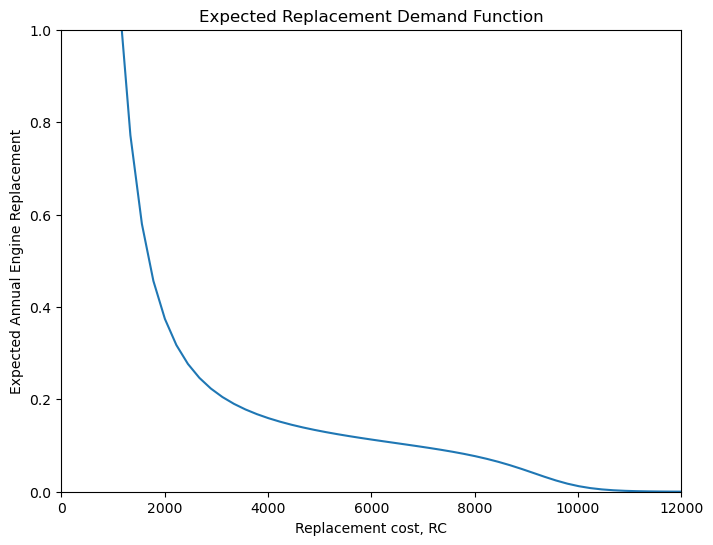

In [5]:
# Expected Demand, as a function of Replacement cost
import copy
mp0 = copy.copy(model_est.RC)
NRC = 59
RCgrid = np.linspace(1,30,NRC)
ev0 = np.zeros((model.n))

Demand = np.empty(NRC)

for i,val in enumerate(RCgrid):
    do_settings = {
    'n': 90,
    'RC': val,
    'c': theta_hat[1],
    'p': np.array(theta_hat[2:])
    }

    model = zurcher(**do_settings)
    _,pk = solver.poly(model.bellman, ev0, beta= model.beta, output=2)
    
    # Find the probability functions
    pp, pp_K, pp_R = model.eqb(pk)
    
    Demand[i] = 12*sum(pp_R)

fig = plt.figure(figsize=(8,6)) 
ax2 = fig.add_subplot(1,1,1)
ax2.plot(RCgrid*scale,Demand)
ax2.set_title(f'Expected Replacement Demand Function')
ax2.set_xlabel("Replacement cost, RC")
ax2.set_ylabel("Expected Annual Engine Replacement")
ax2.set_xlim(0,12000)
ax2.set_ylim(0,1)

plt.show()

#### 4. Estimate the demand function for different values of $\beta$. Does the change in the demand function make intuitive sense?

a) Where do the demand curves cross?

**Answer.** A forward-looking operator internalizes future maintenance costs, so changing $\beta$ changes both the estimated cost parameters and the response of replacement timing to price. After converting both curves to dollars, they cross close to the observed average replacement cost: approximately $\$4,380$, at about $0.147$ expected replacements per year. The exact value varies slightly with numerical estimation.

In [6]:
beta_vec = np.array([0.001, 0.9999])

Demand_beta = np.empty((NRC, 2))
scale_beta = np.empty(2)

for j, beta in enumerate(beta_vec):

    # Set up and estimate the model conditional on beta
    do_settings = {
        'n': 90,
        'beta': beta
    }

    model = zurcher(**do_settings)
    solver = solve_NFXP()

    model_beta, optim_res_beta, pnames_beta, theta_hat_beta, \
        Avar_beta, converged_beta = estimate.estimate(
            model, solver, data
        )

    # Convert normalized replacement costs into dollars
    scale_beta[j] = 4343 / theta_hat_beta[0]

    # Calculate demand for each replacement cost
    ev0 = np.zeros(model_beta.n)

    for i, RC in enumerate(RCgrid):

        demand_settings = {
            'n': 90,
            'beta': beta,
            'RC': RC,
            'c': theta_hat_beta[1],
            'p': np.array(theta_hat_beta[2:])
        }

        demand_model = zurcher(**demand_settings)

        ev0, pk = solver.poly(
            demand_model.bellman,
            ev0,
            beta=beta,
            output=2
        )

        pp, pp_K, pp_R = demand_model.eqb(pk)

        Demand_beta[i, j] = 12 * np.sum(pp_R)

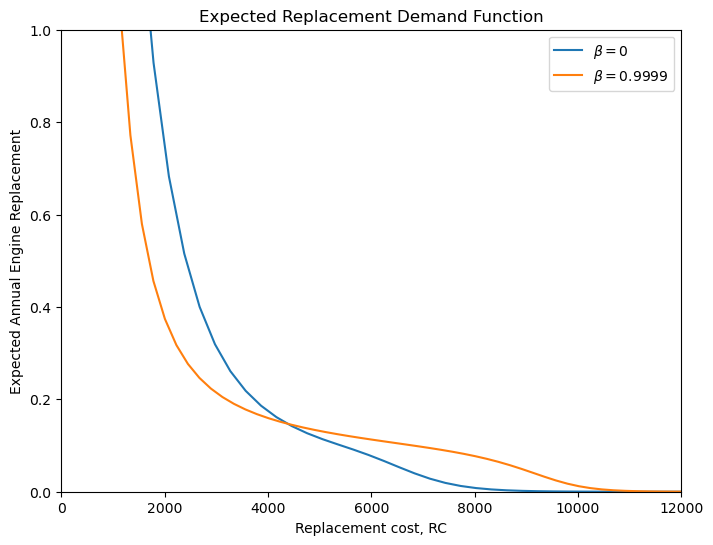

In [7]:
fig = plt.figure(figsize=(8,6)) 
ax2 = fig.add_subplot(1,1,1)
ax2.plot(RCgrid*scale_beta[0],Demand_beta[:,0])
ax2.plot(RCgrid*scale_beta[1],Demand_beta[:,1])
plt.legend((f'$\u03B2=0$',f'$\u03B2= 0.9999$'))
ax2.set_title(f'Expected Replacement Demand Function')
ax2.set_xlabel("Replacement cost, RC")
ax2.set_ylabel("Expected Annual Engine Replacement")
ax2.set_xlim(0,12000)
ax2.set_ylim(0,1)

plt.show()

#### 5. What are the advantages and disadvantages of using a structural model to estimate demand?

**Answer.** The main advantage is that the model recovers economically interpretable primitives and can evaluate counterfactual prices, costs, transition processes, and policies while accounting for forward-looking behavior and the endogenous state distribution. The disadvantages are dependence on functional-form, distributional, equilibrium, and state-transition assumptions; computational cost; possible weak identification; and the risk that misspecification produces misleading counterfactuals.